In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from tqdm import tqdm

In [2]:
class MLP(nn.Module):

    def __init__(self, in_dim, context_dim, h, out_dim):
        super(MLP, self).__init__()
        self.network = nn.Sequential(nn.Linear(in_dim + context_dim, h), nn.Tanh(),
                                     nn.Linear(h, h), nn.Tanh(),
                                     nn.Linear(h, out_dim))

    def forward(self, x, context):
        return self.network(torch.cat((x, context), dim=1))

In [3]:
class Dataset(torch.utils.data.Dataset):
    def __init__(self, dist1, dist2):
        self.dist1 = dist1
        self.dist2 = dist2
        assert self.dist1.shape == self.dist2.shape

    def __len__(self):
        return self.dist1.shape[0]

    def __getitem__(self, idx):
        return self.dist1[idx], self.dist2[idx]

In [4]:
def sample_multimodal_distribution(modes, std, batch_size=1000):
    dataset = []
    for i in range(batch_size):
        sample = np.random.randn(modes.shape[1]) * std
        mode_idx = np.random.randint(modes.shape[0])
        sample[0] += modes[mode_idx, 0]
        sample[1] += modes[mode_idx, 1]
        dataset.append(sample)
    return np.array(dataset, dtype="float32")

In [5]:
def train_rectified_flow(rectified_flow, optimizer, train_dataloader, NB_EPOCHS, eps=1e-15):

    for epoch in tqdm(range(NB_EPOCHS)):
        for z0, z1 in (train_dataloader):

            z0, z1 = z0.to(device), z1.to(device)
            t = torch.rand((z1.shape[0], 1), device=device)
            z_t = t * z1 + (1.-t) * z0
            target = z1 - z0

            pred = rectified_flow(z_t, t)
            loss = (target - pred).view(pred.shape[0], -1).abs().pow(2).sum(dim=1).mean()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

In [6]:
def sample(rectified_flow, T, pi_0):
    samples = [pi_0.clone().unsqueeze(0)]
    for i in (range(T)):
        t = torch.ones((pi_0.shape[0], 1), device=samples[-1].device) * i / T
        drift_pred = rectified_flow(samples[-1].squeeze(0), t)
        samples.append((samples[-1] + drift_pred * 1. / T))
    return torch.cat(samples)

In [7]:
device = 'cuda'
batch_size = 2048
dataset_size = 10_000
nb_epochs = 2_000
wd = 0.01

In [8]:
theta = np.array([0., 60, 120, 180, 240,  300]) / 360 * 2 * np.pi
std = 0.5
radius = 12.
modes = np.array([(radius * x, radius * y) for x, y in zip(np.cos(theta), np.sin(theta))])
pi_0 = sample_multimodal_distribution(modes, std, batch_size=dataset_size)
radius = 5.
modes = np.array([(radius * x, radius * y) for x, y in zip(np.cos(theta), np.sin(theta))])
pi_1 = sample_multimodal_distribution(modes, std, batch_size=dataset_size)

In [9]:
rectified_flow = MLP(2, 1, 64, 2).to(device)
optimizer = torch.optim.Adam(rectified_flow.parameters(), lr=5e-3, weight_decay=wd)
dataset = Dataset(pi_0, pi_1)
train_dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0)
training_loss = train_rectified_flow(rectified_flow, optimizer, train_dataloader, nb_epochs, eps=1e-15)

100%|██████████| 2000/2000 [03:13<00:00, 10.32it/s]


100%|██████████| 999/999 [01:16<00:00, 13.11it/s]


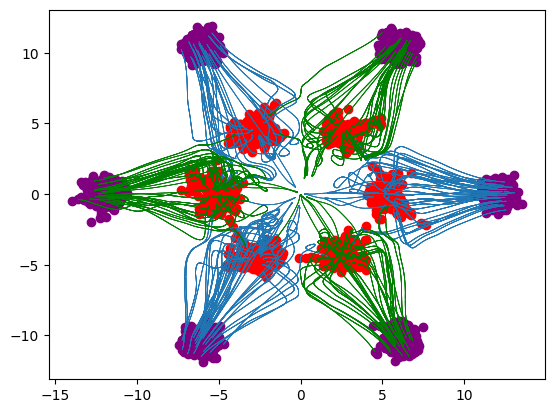

In [11]:
for idx, theta_ in enumerate([theta[::2], theta[1::2]]):
    modes = np.array([(12. * x, 12. * y) for x, y in zip(np.cos(theta_), np.sin(theta_))])

    test_pi_0 = sample_multimodal_distribution(modes, std, batch_size=1000)
    test_pi_1 = sample(rectified_flow, 1000, torch.from_numpy(test_pi_0).to(device))
    plt.scatter(test_pi_0[:, 0], test_pi_0[:, 1], c='purple')
    plt.scatter(test_pi_1[-1, :, 0].data.cpu().numpy(),
                test_pi_1[-1, :, 1].data.cpu().numpy(), c='red')

    for i in tqdm(range(1, 1000, 1)):
        for j in range(0, test_pi_0.shape[0], 10):
            plt.plot([test_pi_1[i-1, j, 0].item(), test_pi_1[i, j, 0].item()],
                     [test_pi_1[i-1, j, 1].item(), test_pi_1[i, j, 1].item()],
                     c="C0" if idx == 0 else 'g', linewidth=.5)
plt.show()